In [183]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import torch
import torch.nn as nn
import torch.optim as optim
from matplotlib.animation import FuncAnimation
import time
import sympy

In [184]:
T   = 100.0

Nt = 1000

alpha = 0.6666
beta = 1.3333
gamma = 1
delta = 1

alpha = alpha
beta = beta
gamma = gamma
delta = delta

x0 = 1.8
y0 = 1.8



## Runge Kutta

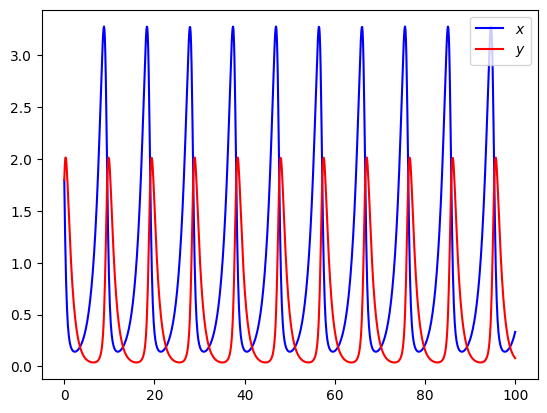

In [185]:
def Lotka_Volterra(t,x,y):
  dx = x * (alpha - beta * y)
  dy = -y * (gamma - delta * x)
  return [dx,dy]

t_rk = np.linspace(0,T,Nt)
x_rk = np.zeros(Nt)
y_rk = np.zeros(Nt)

x_rk[0] = x0
y_rk[0] = y0

dt = T/Nt

for id_t, val_t in enumerate(t_rk[:-1]):
  k1 = Lotka_Volterra(val_t, x_rk[id_t], y_rk[id_t])
  k2 = Lotka_Volterra(val_t + dt/2, x_rk[id_t] + dt*k1[0]/2, y_rk[id_t] + dt*k1[1]/2)
  k3 = Lotka_Volterra(val_t + dt/2, x_rk[id_t] + dt*k2[0]/2, y_rk[id_t] + dt*k2[1]/2)
  k4 = Lotka_Volterra(val_t + dt, x_rk[id_t] + dt*k3[0], y_rk[id_t] + dt*k3[1])

  x_rk[id_t+1] = x_rk[id_t] + dt/6 * (k1[0] + 2*k2[0] + 2*k3[0] + k4[0])
  y_rk[id_t+1] = y_rk[id_t] + dt/6 * (k1[1] + 2*k2[1] + 2*k3[1] + k4[1])


plt.plot(t_rk, x_rk,"-b",label = r"$x$")
plt.plot(t_rk, y_rk,"-r",label = r"$y$")
plt.legend()
plt.show()

## PINN

### Modelo

In [186]:
#
# =====================================================================
# 1. CONFIGURACIÓN DE GPU/CUDA
# =====================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    print("CUDA disponible. Usando GPU para entrenamiento.")
else:
    print("CUDA no disponible. Usando CPU para entrenamiento.")

# =====================================================================
# 2. SELECCIÓN DE FUNCIÓN DE ACTIVACIÓN Y PARÁMETROS DEL DOMINIO
# =====================================================================
ACTIVATION_TYPE = 'tanh'
VARIABLES = 2
PARAMETROS = 4
class SinActivation(nn.Module):
    def forward(self, x):
        return torch.sin(x)

def get_activation():
    if ACTIVATION_TYPE == 'sin':
        return SinActivation()
    elif ACTIVATION_TYPE == 'sigmoid':
      return nn.Sigmoid()
    elif ACTIVATION_TYPE == 'tanh':
      return nn.Tanh()
    elif ACTIVATION_TYPE == 'SiLU':
      return nn.SiLU()
    else:
        raise ValueError(f"Función de activación no reconocida: {ACTIVATION_TYPE}")

class PINN(nn.Module):
    def __init__(self, activation_fn):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),   activation_fn,
            nn.Linear(64, 128), activation_fn,
            nn.Linear(128, 128),activation_fn,
            nn.Linear(128, 128),activation_fn,
            nn.Linear(128, 64), activation_fn,
            nn.Linear(64, VARIABLES)

        )

        self.log_alpha = nn.Parameter(torch.tensor([0.0]))
        self.log_beta  = nn.Parameter(torch.tensor([0.0]))
        self.log_gamma = nn.Parameter(torch.tensor([0.0]))
        self.log_delta = nn.Parameter(torch.tensor([0.0]))


        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
      return self.net(x)

    def parametros_fisicos(self):
        return (self.log_alpha.exp(), self.log_beta.exp(),
                self.log_gamma.exp(), self.log_delta.exp())

def build_model():
    activation_fn = get_activation()
    return PINN(activation_fn)




CUDA no disponible. Usando CPU para entrenamiento.


### Perdida

In [187]:
def muestrear_interior(N, device ):
    """N puntos aleatorios (t) en el interior del dominio, para el residuo de la PDE."""
    feature =  torch.rand(N, 1, device=device)
    feature.requires_grad_(True)
    return feature

def edo_func(modelo, feature):

    pred = modelo(feature)
    # x
    x = pred[:, 0:1]
    dx = torch.autograd.grad(x, feature, grad_outputs=torch.ones_like(x), create_graph=True)[0]

    # y
    y = pred[:, 1:2]
    dy = torch.autograd.grad(y, feature, grad_outputs=torch.ones_like(y), create_graph=True)[0]

    # Parametros
    alpha, beta, gamma, delta = modelo.parametros_fisicos()
    # loss

    Loss_v = dx - x * (alpha - beta * y)
    Loss_w = dy + y * (gamma - delta * x)

    return Loss_v, Loss_w

def Observaciones(modelo, feature_obs, obs):

    model_pred = modelo(feature_obs)
    # v
    x = model_pred[:, 0:1]
    # w
    y = model_pred[:, 1:2]

    loss_obs = torch.mean((x - obs["x"] ) ** 2) + torch.mean((y - obs["y"]  ) ** 2)

    return loss_obs

def pesos_causales(Loss_v,Loss_w,feature):
    epsilon_causal = 0.1
    residuo_puntual = Loss_v**2 + Loss_w**2

    tau_vals = feature.detach()[:, 0]
    idx_orden = torch.argsort(tau_vals)
    res_ordenado = residuo_puntual[idx_orden, 0]

    with torch.no_grad():
        res_para_cumsum = res_ordenado.detach()
        cumsum = torch.cumsum(res_para_cumsum, dim=0)
        cumsum = torch.roll(cumsum, 1)
        cumsum[0] = 0.0
        pesos = torch.exp(-epsilon_causal * cumsum)  # shape (N,)

    res_ponderado = pesos * res_ordenado

    return torch.mean(res_ponderado)

def actualizar_pesos(modelo,zeta_obs,zeta_nau):
  grad_obs  = torch.autograd.grad(zeta_obs, modelo.net.parameters(), retain_graph=True, create_graph=False)
  grad_ode = torch.autograd.grad(zeta_nau,     modelo.net.parameters(), retain_graph=True, create_graph=False)

  with torch.no_grad():
    norm_obs  = sum(g.norm()**2 for g in grad_obs  if g is not None).sqrt()
    norm_ode = sum(g.norm()**2 for g in grad_ode if g is not None).sqrt()

  peso_obs  = (norm_obs + norm_ode) / (norm_obs  + 1e-8)
  peso_ode = (norm_obs + norm_ode) / (norm_ode + 1e-8)
  return peso_ode, peso_obs

def perdida(modelo, feature_obs, obs, N_ode, i, expand = False, upt_pesos = True):
    feature_pde = muestrear_interior(N_ode, device)
    L_v, L_w = edo_func(modelo, feature_pde)
    zeta_nau = pesos_causales(L_v,L_w, feature_pde)
    #zeta_nau = torch.mean(L_v**2) + torch.mean(L_w**2)
    zeta_obs = Observaciones(modelo,feature_obs, obs)

    if upt_pesos == False:
      peso_edo , peso_obs = 1,1
    else:
      peso_edo , peso_obs = actualizar_pesos(modelo, zeta_obs, zeta_nau)

    if expand:
        return [zeta_nau , zeta_obs * peso_obs]
    else:
        return [zeta_nau  + peso_obs * zeta_obs]



### entrenamiento

In [188]:
def train_step(modelo, optimi, feature_obs, obs, i, N_ode, expand = False):
    optimi.zero_grad()
    loss = perdida(modelo, feature_obs, obs, N_ode, i, expand = expand)
    if expand:
        loss_total = loss[0] + loss[1]
    else:
        loss_total = loss[0]
    loss_total.backward()
    optimi.step()
    return loss


def optimizar(modelo, feature_obs, obs, N=40000, N_ode=4000 ):
    """
    N_ode: puntos interiores nuevos por iteración (residuo ODE)
    Todos se resamplean en cada llamada a train_step -> cada iteración
    ve un set de puntos de colocación distinto.
    """
    optimi = optim.Adam(modelo.parameters(), lr=0.003)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimi, T_max=N, eta_min=1e-5)

    err = []
    exp = True
    for i in range(N):

        loss = train_step(modelo,optimi, feature_obs, obs, i, N_ode, expand = exp)
        scheduler.step()
        loss_val = sum(l.item() for l in loss)

       # total_norm = torch.nn.utils.clip_grad_norm_(modelo.parameters(), max_norm=1.0)

        if i % 100 == 0:
            #print(f"  grad_norm: {total_norm:.4f}")
            if exp:
              print("Entrenamiento :", i, " | Perdida:", loss_val," | Perdida EDO :", loss[0].item(), " | Perdida Observaciones :", loss[1].item())
            else:
              print("Entrenamiento :", i, " | Perdida :", loss_val)
        err.append(loss_val)
    return err



### ejecutar

Tiempo antes del entrenamiento: 0.003259420394897461 segundos
Entrenamiento : 0  | Perdida: 2.5441264137625694  | Perdida EDO : 0.019222401082515717  | Perdida Observaciones : 2.5249040126800537
Entrenamiento : 100  | Perdida: 2.7254546592012048  | Perdida EDO : 0.011785359121859074  | Perdida Observaciones : 2.7136693000793457
Entrenamiento : 200  | Perdida: 7.9156622076407075  | Perdida EDO : 0.006537833251059055  | Perdida Observaciones : 7.909124374389648
Entrenamiento : 300  | Perdida: 1.78233397542499  | Perdida EDO : 0.002582555403932929  | Perdida Observaciones : 1.7797514200210571
Entrenamiento : 400  | Perdida: 1.9514093538746238  | Perdida EDO : 0.013630642555654049  | Perdida Observaciones : 1.9377787113189697
Entrenamiento : 500  | Perdida: 6.734184577129781  | Perdida EDO : 0.013287379406392574  | Perdida Observaciones : 6.720897197723389
Entrenamiento : 600  | Perdida: 2.750432870350778  | Perdida EDO : 0.006064794026315212  | Perdida Observaciones : 2.744368076324463
En

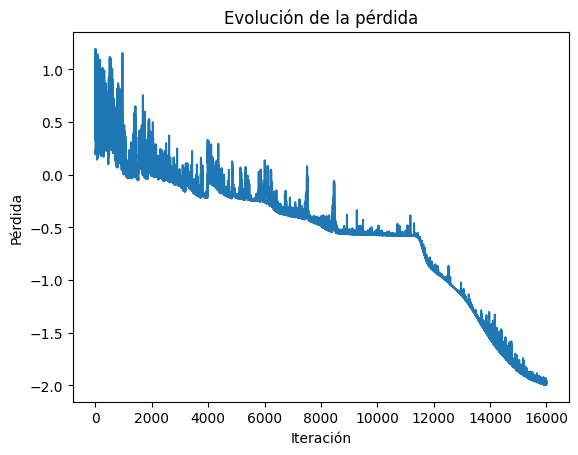

In [189]:
import random

inicio = time.time()
model = build_model().to(device)

fin = time.time()
print("Tiempo antes del entrenamiento:", fin - inicio, "segundos")
inicio = time.time()

# muestreo de observaciones
N_obs = 200
id_obs = np.random.choice(np.arange(Nt), size = N_obs, replace=False)
x_obs = torch.from_numpy(x_rk[id_obs]).float().unsqueeze(1)
y_obs = torch.from_numpy(y_rk[id_obs]).float().unsqueeze(1)
var_obs = {"x":x_obs,"y":y_obs}
t_obs = torch.from_numpy(t_rk[id_obs]).float().unsqueeze(1)

opt = optimizar(model, t_obs, var_obs, N=16000, N_ode=400)
fin = time.time()
print("Tiempo del entrenamiento:", fin - inicio, "segundos")

plt.plot(range(len(opt)), np.log10(opt))
plt.xlabel("Iteración")
plt.ylabel("Pérdida")
plt.title("Evolución de la pérdida")
plt.show()



### Visualizacion

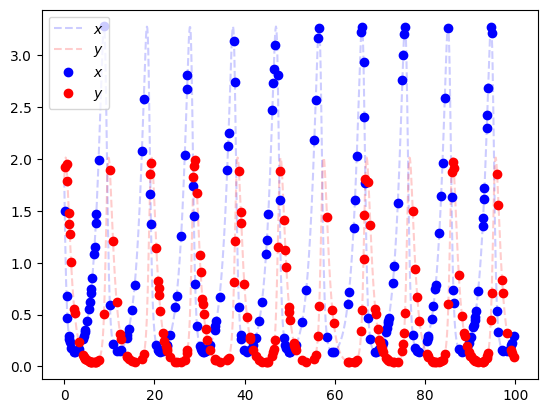

In [190]:
plt.plot(t_rk, x_rk,"--b",label = r"$x$",alpha = 0.2)
plt.plot(t_rk, y_rk,"--r",label = r"$y$", alpha = 0.2)

plt.plot(t_obs,x_obs,"ob",label = r"$x$")
plt.plot(t_obs,y_obs,"or",label = r"$y$")
plt.legend()
plt.show()

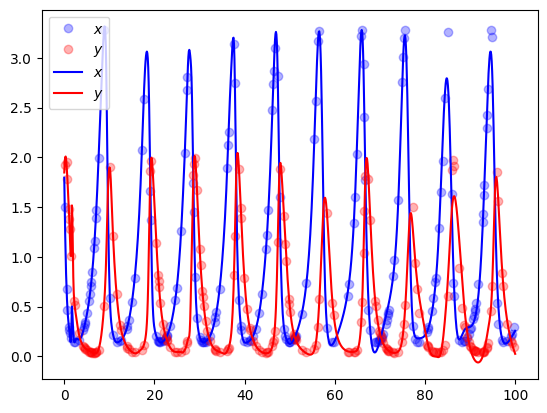

In [191]:
plt.plot(t_obs,x_obs,"ob",label = r"$x$",alpha = 0.3)
plt.plot(t_obs,y_obs,"or",label = r"$y$", alpha = 0.3)
with torch.no_grad():
  model_pred = model(torch.from_numpy(t_rk).float().unsqueeze(1) ).cpu().numpy()
x_pred = model_pred[:, 0:1]
y_pred = model_pred[:, 1:2]

plt.plot(t_rk, x_pred,"-b",label = r"$x$")
plt.plot(t_rk, y_pred,"-r",label = r"$y$")
plt.legend()
plt.show()

In [192]:
alpha_model,beta_model,gamma_model,delta_model = model.parametros_fisicos()
print(f"alpha model : {alpha_model.item()} | alpha real : {alpha}")
print(f"beta model : {beta_model.item()} | beta real : {beta}")
print(f"gamma model : {gamma_model.item()} | gamma real : {gamma}")
print(f"delta model : {delta_model.item()} | delta real : {delta}")


alpha model : 0.698782205581665 | alpha real : 0.6666
beta model : 1.3302974700927734 | beta real : 1.3333
gamma model : 0.9225943088531494 | gamma real : 1
delta model : 0.8738268613815308 | delta real : 1
